In [15]:
import numpy as np
import pandas as pd
import librosa

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, BatchNormalization, Bidirectional, LSTM
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [16]:
df_train = pd.read_csv(r"D:\SER_Cross\data\processed\train.csv")
df_val   = pd.read_csv(r"D:\SER_Cross\data\processed\val.csv")
df_test  = pd.read_csv(r"D:\SER_Cross\data\processed\test.csv")

In [17]:
emotions = ['angry', 'happy', 'sad']

df_train = df_train[df_train['emotion'].isin(emotions)]
df_val   = df_val[df_val['emotion'].isin(emotions)]
df_test  = df_test[df_test['emotion'].isin(emotions)]

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(df_train['emotion'])
y_val   = le.transform(df_val['emotion'])
y_test  = le.transform(df_test['emotion'])

y_train_cat = to_categorical(y_train)
y_val_cat   = to_categorical(y_val)
y_test_cat  = to_categorical(y_test)

In [19]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050)

    max_len = 3 * sr
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    combined = np.vstack([mfcc, delta, delta2])  # (120, time)

    return combined.T   # (time, 120)

In [20]:
def build_dataset(df):
    X = []
    y = []

    for i in range(len(df)):
        try:
            features = extract_features(df.iloc[i]['path'])
            X.append(features)
            y.append(df.iloc[i]['emotion'])
        except:
            pass

    return np.array(X), np.array(y)

In [21]:
X_train, _ = build_dataset(df_train)
X_val, _   = build_dataset(df_val)
X_test, _  = build_dataset(df_test)

In [22]:
model = Sequential()

model.add(Conv1D(128, 3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.4))

model.add(Conv1D(256, 3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.4))

model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.4))

model.add(Bidirectional(LSTM(128)))
model.add(Dropout(0.4))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(3, activation='softmax'))

In [23]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3)
early_stop   = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

In [25]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=40,
    batch_size=32,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/40
97/97 [==============================] - 19s 148ms/step - loss: 0.8130 - accuracy: 0.6167 - val_loss: 0.8558 - val_accuracy: 0.5942 - lr: 5.0000e-04
Epoch 2/40
97/97 [==============================] - 13s 135ms/step - loss: 0.7147 - accuracy: 0.6796 - val_loss: 0.8260 - val_accuracy: 0.6457 - lr: 5.0000e-04
Epoch 3/40
97/97 [==============================] - 13s 138ms/step - loss: 0.6405 - accuracy: 0.7202 - val_loss: 0.8803 - val_accuracy: 0.6473 - lr: 5.0000e-04
Epoch 4/40
97/97 [==============================] - 13s 135ms/step - loss: 0.5832 - accuracy: 0.7484 - val_loss: 0.7397 - val_accuracy: 0.6989 - lr: 5.0000e-04
Epoch 5/40
97/97 [==============================] - 13s 139ms/step - loss: 0.5415 - accuracy: 0.7675 - val_loss: 0.8188 - val_accuracy: 0.6667 - lr: 5.0000e-04
Epoch 6/40
97/97 [==============================] - 13s 136ms/step - loss: 0.5180 - accuracy: 0.7870 - val_loss: 0.8401 - val_accuracy: 0.6957 - lr: 5.0000e-04
Epoch 7/40
97/97 [======================

In [26]:
loss, acc = model.evaluate(X_test, y_test_cat)

print("CRNN Test Accuracy:", acc)

22/22 [==============================] - 1s 29ms/step - loss: 0.4727 - accuracy: 0.8056
CRNN Test Accuracy: 0.8055555820465088


In [27]:
print(" Training Accuracy:", history.history['accuracy'][-1])

 Training Accuracy: 0.8563553690910339


In [28]:
model.save("final_crnn_model.h5")

c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


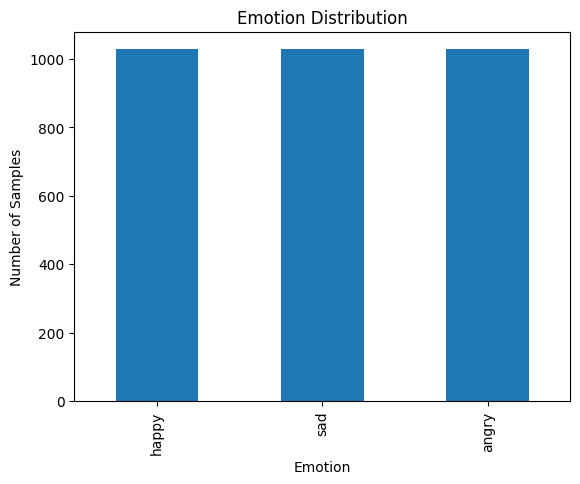

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\SER_Cross\data\processed\train.csv")

# Filter only 3 emotions
df = df[df['emotion'].isin(['angry', 'happy', 'sad'])]

counts = df['emotion'].value_counts()

plt.figure()
counts.plot(kind='bar')

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")

plt.show()

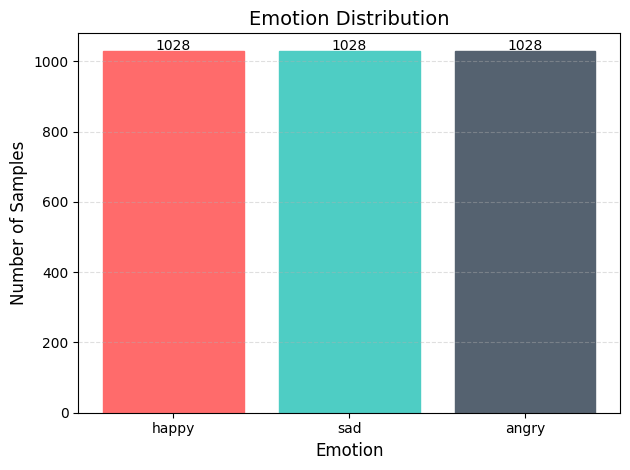

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\SER_Cross\data\processed\train.csv")
df = df[df['emotion'].isin(['angry', 'happy', 'sad'])]

counts = df['emotion'].value_counts()

plt.figure()

bars = plt.bar(counts.index, counts.values)

# Soft professional colors
colors = ['#FF6B6B', '#4ECDC4', '#556270']
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Add values on top
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.title("Emotion Distribution", fontsize=14)
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

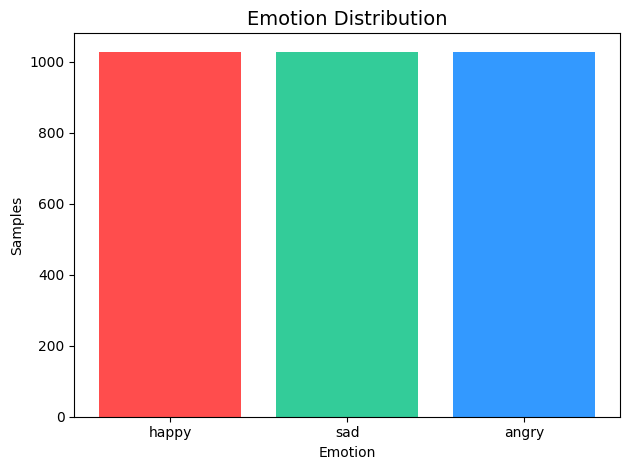

In [32]:
plt.figure()

plt.bar(counts.index, counts.values,
        color=['#ff4d4d', '#33cc99', '#3399ff'])

plt.title("Emotion Distribution", fontsize=14)
plt.xlabel("Emotion")
plt.ylabel("Samples")

plt.tight_layout()
plt.show()

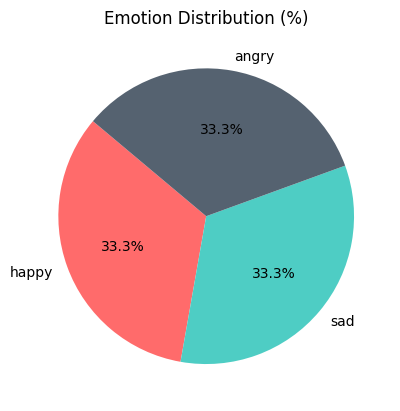

In [33]:
plt.figure()

plt.pie(counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=['#FF6B6B', '#4ECDC4', '#556270'],
        startangle=140)

plt.title("Emotion Distribution (%)")
plt.show()